In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load Dataset
df = pd.read_csv("Agricultural_Yield.csv")

print(df.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

  crop_type soil_type  yield_ton_per_hectare  
0     Maize     Loamy                   5.92  
1     Maize     Sandy                   6.24  
2     Wheat     Sandy                   4.77  
3     Maize     Loamy                   4.04  
4    Cotton      Clay                   5.17  


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 10 Records:")
print(df.head(10))

Shape: (1500, 8)

Columns:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4       

In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   crop_type              1500 non-null   object 
 6   soil_type              1500 non-null   object 
 7   yield_ton_per_hectare  1500 non-null   float64
dtypes: float64(6), object(2)
memory usage: 93.9+ KB
None

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [6]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


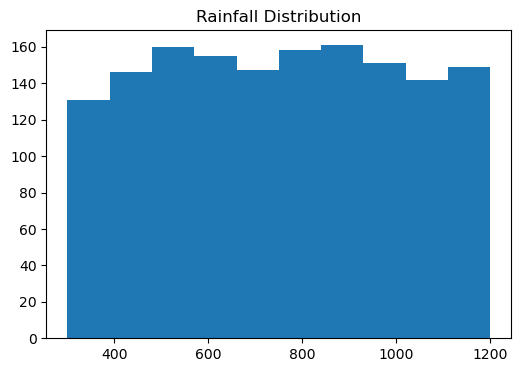

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'])
plt.title("Rainfall Distribution")
plt.show()

In [10]:
corr = df[['temperature_c',
           'fertilizer_kg',
           'yield_ton_per_hectare']].corr()

print(corr)

                       temperature_c  fertilizer_kg  yield_ton_per_hectare
temperature_c               1.000000       0.037468              -0.022559
fertilizer_kg               0.037468       1.000000               0.278043
yield_ton_per_hectare      -0.022559       0.278043               1.000000


In [11]:
print(df['crop_type'].value_counts())

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


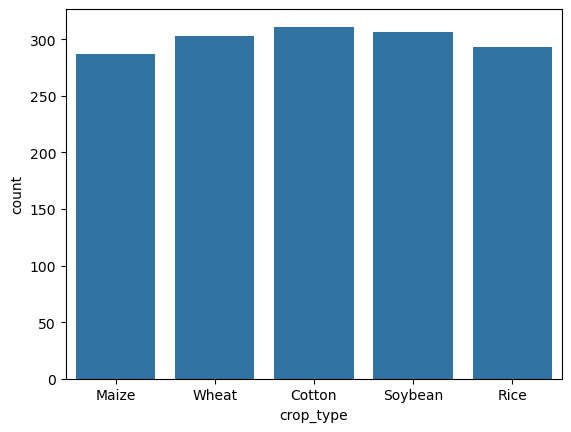

In [12]:
sns.countplot(x='crop_type', data=df)
plt.show()

In [13]:
print(df['soil_type'].value_counts())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


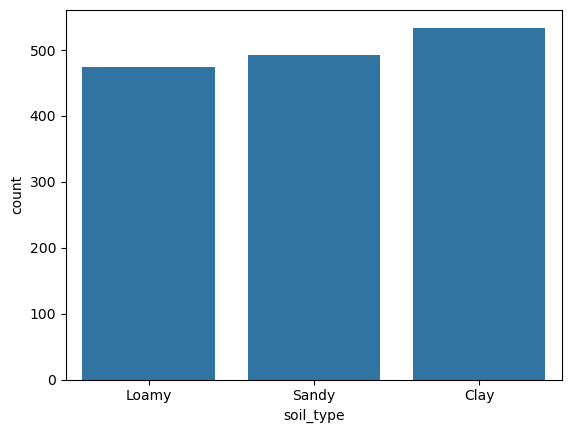

In [14]:
sns.countplot(x='soil_type', data=df)
plt.show()

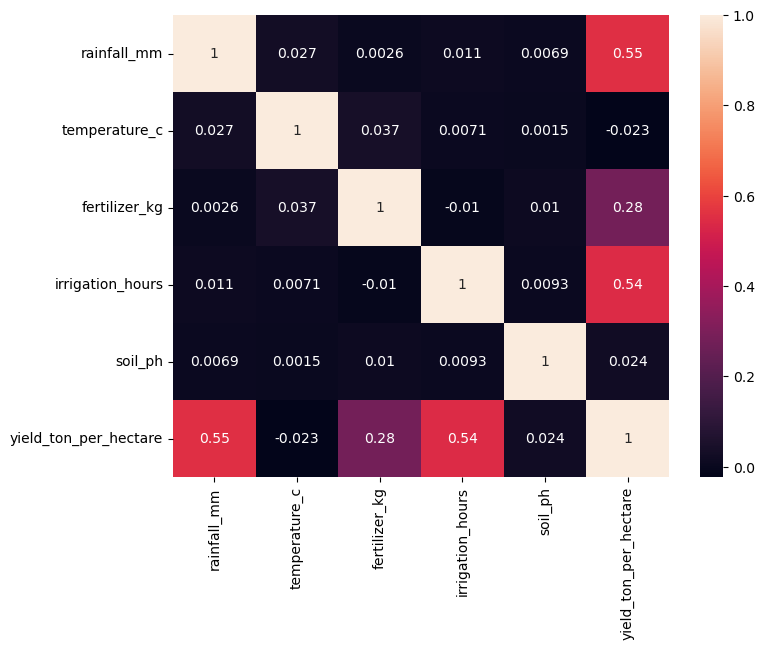

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

In [16]:
encoded_df = pd.get_dummies(df, drop_first=True)

encoded_df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [17]:
from sklearn.model_selection import train_test_split

X = encoded_df.drop("yield_ton_per_hectare", axis=1)
y = encoded_df["yield_ton_per_hectare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1200, 11)
(300, 11)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

Intercept:
1.587132027736132


In [19]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974
5,crop_type_Maize,0.238931
3,irrigation_hours,0.198327
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
